<a href="https://colab.research.google.com/github/Werianin/shift-MLI-2026/blob/main/research_SHIFT_INTENSIVE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import VarianceThreshold
# from catboost import CatBoostClassifier

In [ ]:
np.random.seed(42)

In [ ]:
methods = []
auc_values = []

In [ ]:
# Список понадобится при составлении функции подготовки DF на финальном этапе
cols_to_drop = [] # Список признаков, которые нужно удалить из выборки

In [ ]:
df = pd.read_csv('/df_train_full.csv')
df_test = pd.read_csv('/X_test.csv')

In [ ]:
df.head()

,Год_рождения,Подписаны_документы,Пол,БылПростой,ОпытВДолжности,Активность,Знак_зодиака,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Образование,Телефон,Город,Размер,Закрытые_проекты,ГодНайма,Курсы,Увольнение
0,2002.0,Да,NaN,No,NaN,317.0,Козерог,25.0,2.0,3.0,0.0,Bachelors,917445816222,Bangalore,L,13.0,2013.0,2.0,1
1,2002.0,Да,Male,No,3.0,317.0,Козерог,25.0,2.0,3.0,NaN,Bachelors,917445816222,Bangalore,L,NaN,2013.0,2.0,1
2,2002.0,Да,Male,No,3.0,NaN,Козерог,25.0,2.0,3.0,0.0,Bachelors,917445816222,Bangalore,L,NaN,2013.0,2.0,1
3,2002.0,Да,Male,No,3.0,317.0,Козерог,25.0,NaN,3.0,0.0,Bachelors,917445816222,Bangalore,L,NaN,2013.0,2.0,1
4,2002.0,Да,Male,No,3.0,317.0,Козерог,25.0,2.0,NaN,0.0,NaN,917445816222,Bangalore,L,13.0,2013.0,NaN,1


In [ ]:
def collapse_duplicates(df):
    print(f"Строк до объединения: {len(df)}")

    # Группируем по телефону и берем первое НЕ пустое значение (first)
    df_collapsed = df.groupby('Телефон', as_index=False).first()

    print(f"Строк после объединения: {len(df_collapsed)}")
    return df_collapsed

In [ ]:
df_collapsed = collapse_duplicates(df)

Строк до объединения: 8357
Строк после объединения: 2764


In [ ]:
missing_values = df_collapsed.isnull().sum()
print("Количество пустых полей в каждом столбце df_collapsed:")
print(missing_values[missing_values > 0])

Количество пустых полей в каждом столбце df_collapsed:
Год_рождения           130
Подписаны_документы    114
Пол                    141
БылПростой             145
ОпытВДолжности         157
Активность             121
Знак_зодиака           144
Возраст                137
Оценка_HR              139
УровеньОплаты          137
Офлайн_участие         117
Образование            139
Город                  126
Размер                 130
Закрытые_проекты       139
ГодНайма               123
Курсы                  121
dtype: int64


In [ ]:
X = df_collapsed
y = np.array(df_collapsed['Увольнение'])

In [ ]:
def fill_nans(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'object':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())
    return df

In [ ]:
X = fill_nans(X)

## Target Encoding
Проверим подозрительные категориальные поля.

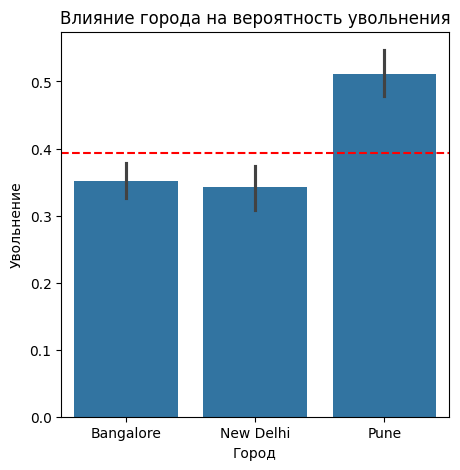

In [ ]:
plt.figure(figsize=(5, 5))
# Показываем долю увольнений для каждой категории признака
sns.barplot(x='Город', y='Увольнение', data=X)
plt.axhline(X['Увольнение'].mean(), color='red', linestyle='--', label='Среднее по компании')
plt.title('Влияние города на вероятность увольнения')
plt.show()

In [ ]:
# Bangalore и New Delhi: Средняя доля увольнений практически идентична — около 35%, значит можно их объединить, упрощая обучение модели.
X['Город'] = X['Город'].replace({
    'Bangalore': 'Big_City',
    'New Delhi': 'Big_City'
})

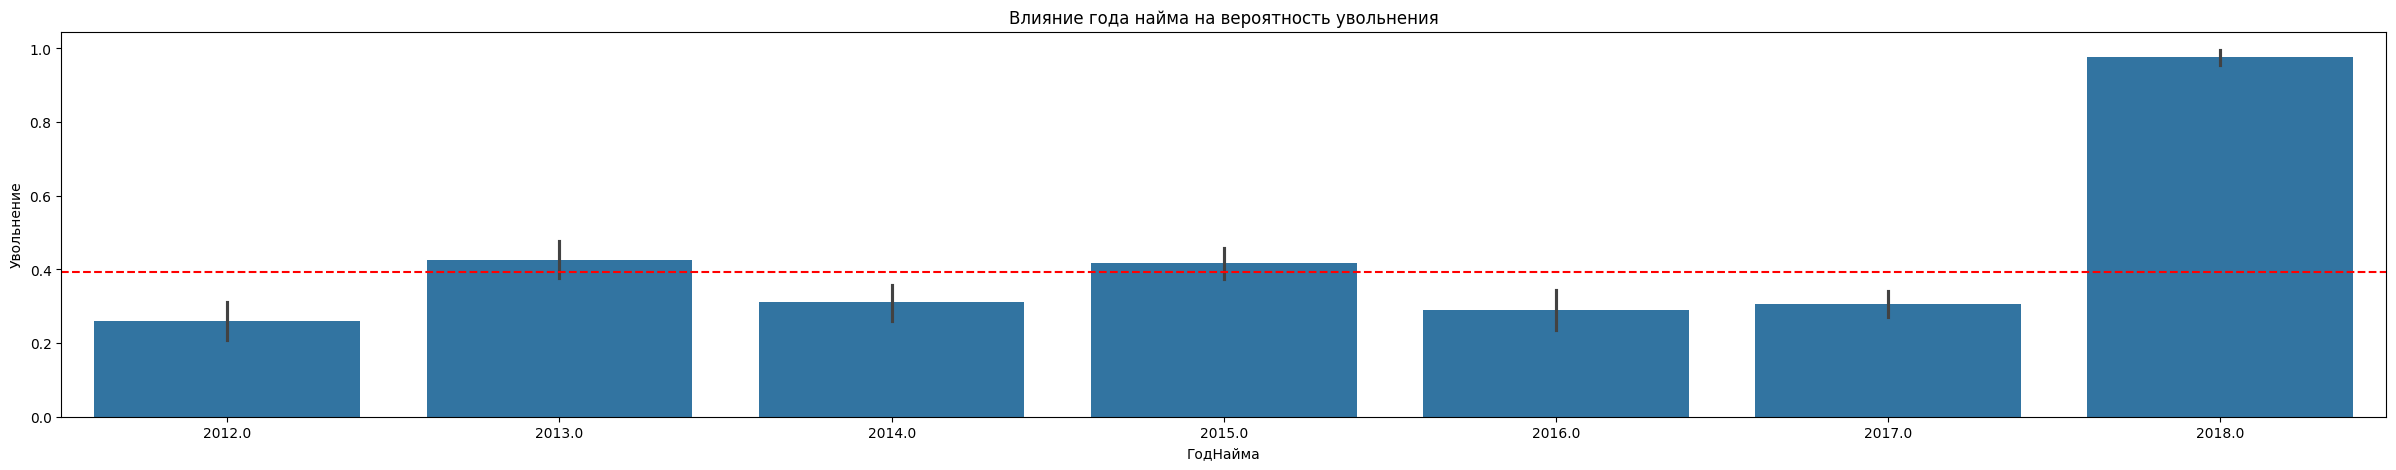

In [ ]:
plt.figure(figsize=(30, 5))
# Показываем долю увольнений (y) для каждой категории признака
sns.barplot(x='ГодНайма', y='Увольнение', data=X)
plt.axhline(X['Увольнение'].mean(), color='red', linestyle='--', label='Среднее по компании')
plt.title('Влияние года найма на вероятность увольнения')
plt.show()

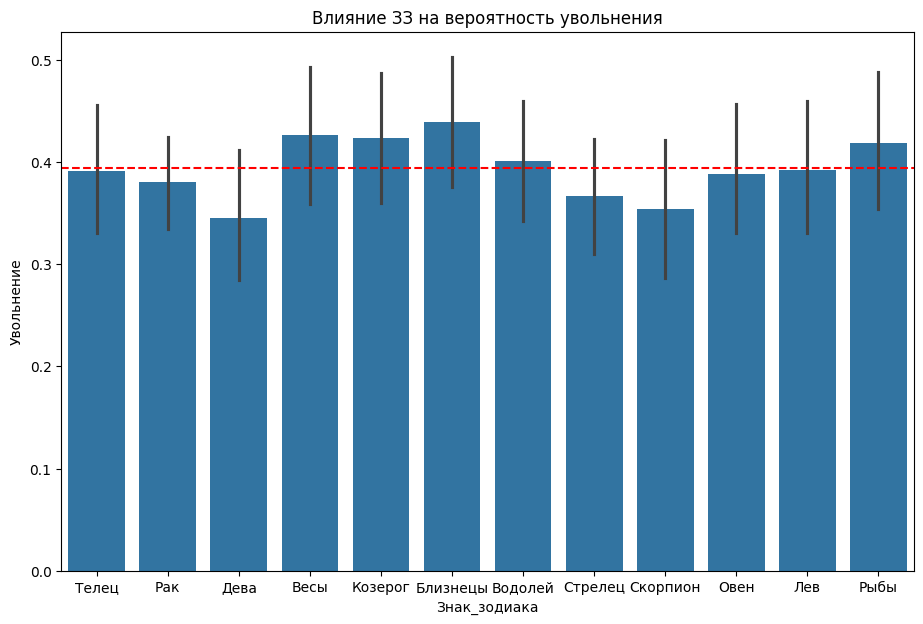

In [ ]:
plt.figure(figsize=(11, 7))
# Показываем долю увольнений (y) для каждой категории признака
sns.barplot(x='Знак_зодиака', y='Увольнение', data=X)
plt.axhline(X['Увольнение'].mean(), color='red', linestyle='--', label='Среднее по компании')
plt.title('Влияние ЗЗ на вероятность увольнения')
plt.show()

In [ ]:
# Показано отсутствие значимых отклонений от среднего уровня целевой переменной для всех групп.
# Доверительные интервалы всех категорий пересекаются, что подтверждает отсутствие статистической связи.
# Признак можно считать шумовым и исключить из модели.
to_drop = ['Знак_зодиака']
cols_to_drop.extend(to_drop)
X = X.drop(columns=to_drop)

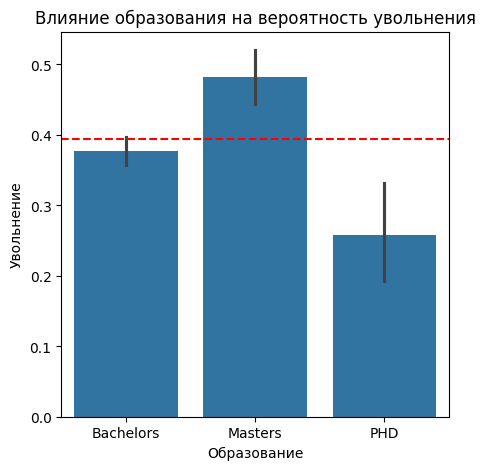

In [ ]:
plt.figure(figsize=(5, 5))
# Показываем долю увольнений (y) для каждой категории признака
sns.barplot(x='Образование', y='Увольнение', data=X)
plt.axhline(X['Увольнение'].mean(), color='red', linestyle='--', label='Среднее по компании')
plt.title('Влияние образования на вероятность увольнения')
plt.show()

In [ ]:
# Даем веса согласно стабильности: PHD (0) -> Bachelor (1) -> Masters (2)
edu_map = {'PHD': 0, 'Bachelors': 1, 'Masters': 2}
X['Образование'] = X['Образование'].map(edu_map)

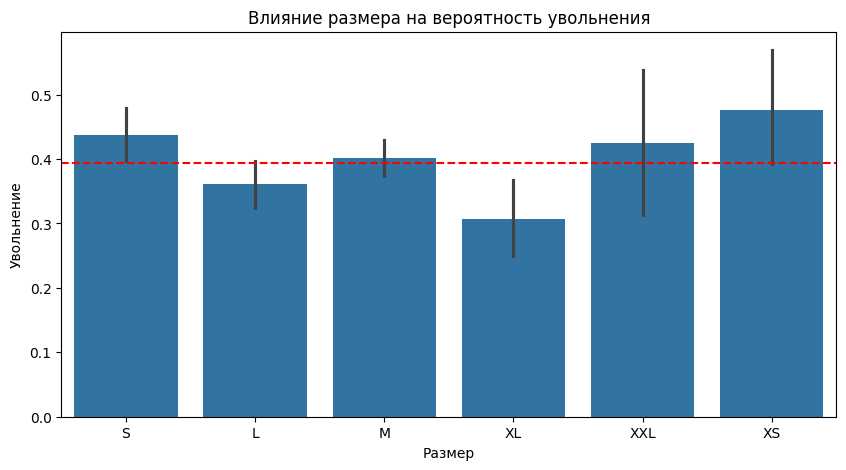

In [ ]:
plt.figure(figsize=(10, 5))
# Показываем долю увольнений (y) для каждой категории признака
sns.barplot(x='Размер', y='Увольнение', data=X)
plt.axhline(X['Увольнение'].mean(), color='red', linestyle='--', label='Среднее по компании')
plt.title('Влияние размера на вероятность увольнения')
plt.show()

In [ ]:
# Признак 'Размер' мы исключаем из модели как избыточный, так как он сильно коррелирует с признаком 'Пол'
# Признак не несет самостоятельной предсказательной ценности, то есть является косвенным показателем
to_drop = ['Размер']
cols_to_drop.extend(to_drop)
X = X.drop(columns=to_drop)

In [ ]:
def encode_categorical_features(df):
    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = le.fit_transform(df[col].astype(str))
    return df

In [ ]:
X = encode_categorical_features(X)

## Распределение

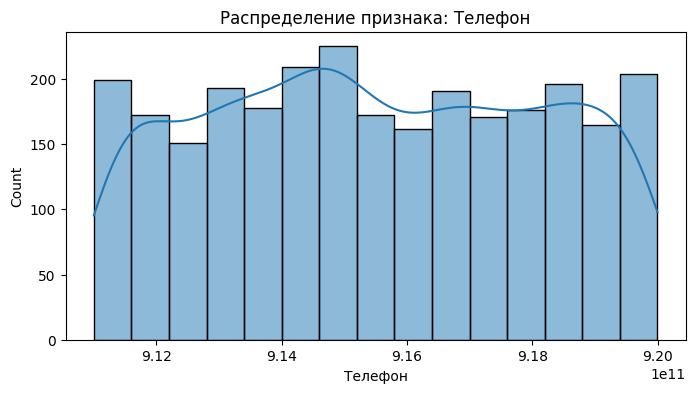

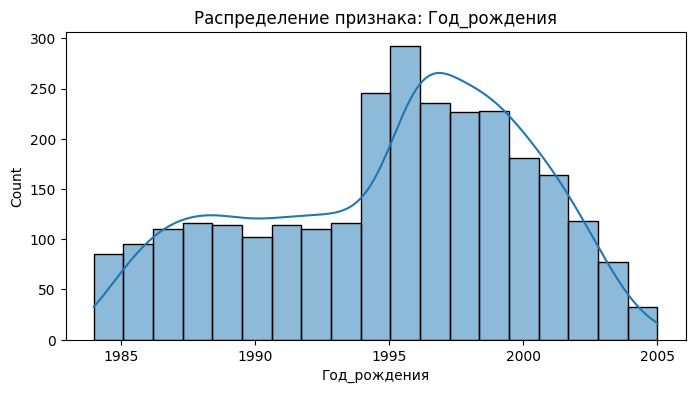

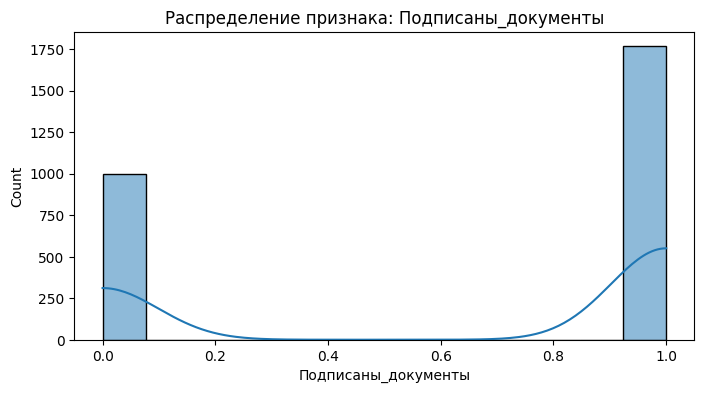

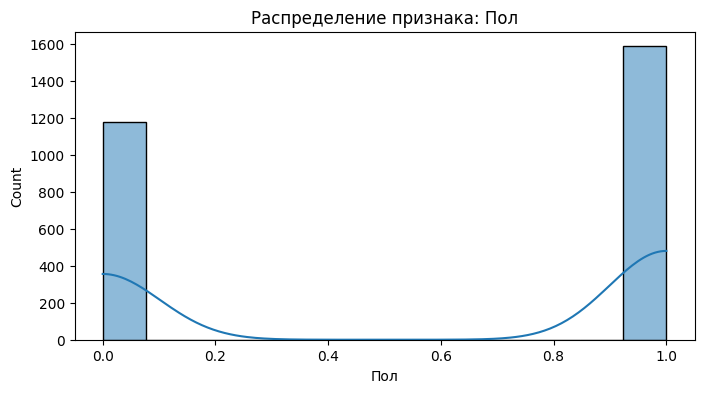

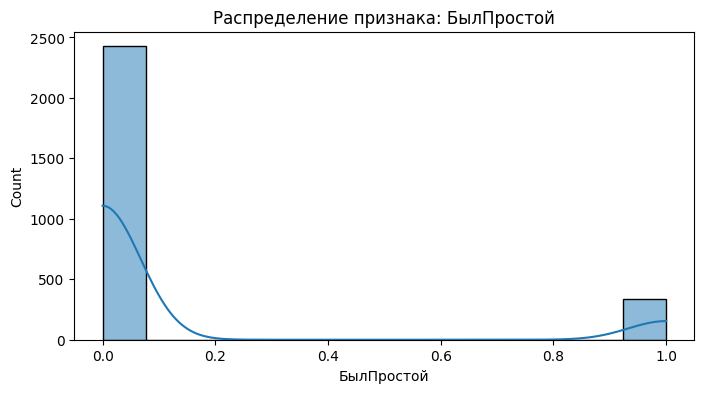

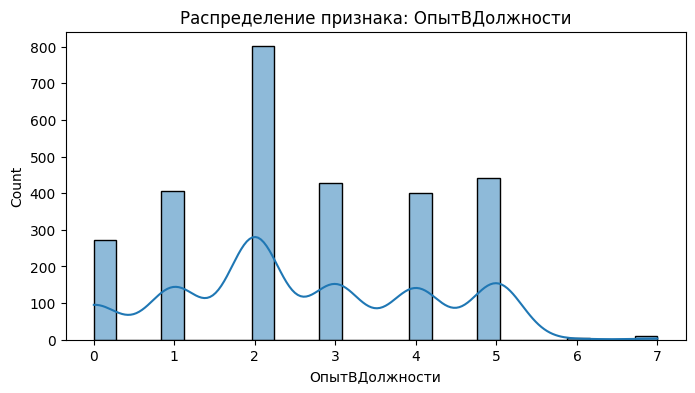

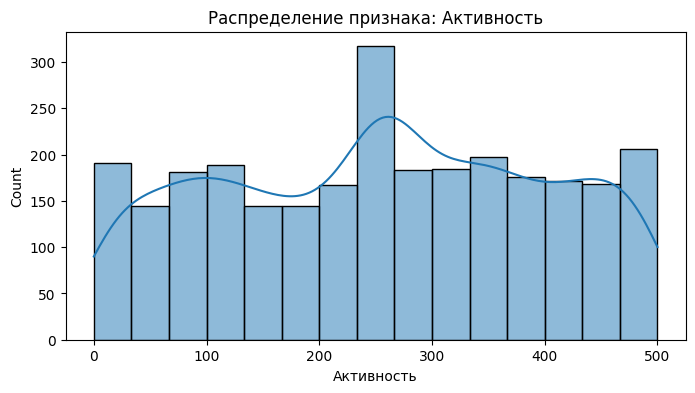

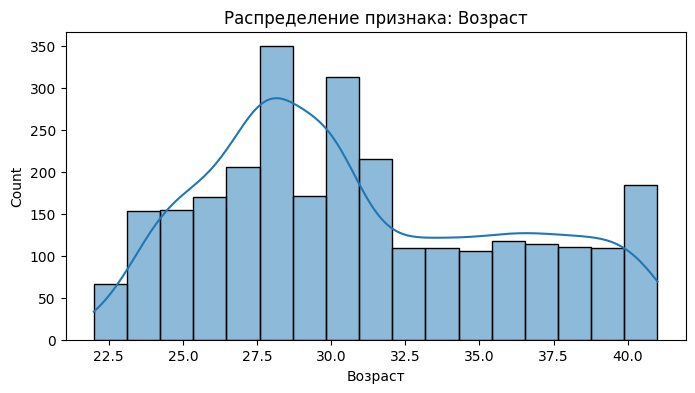

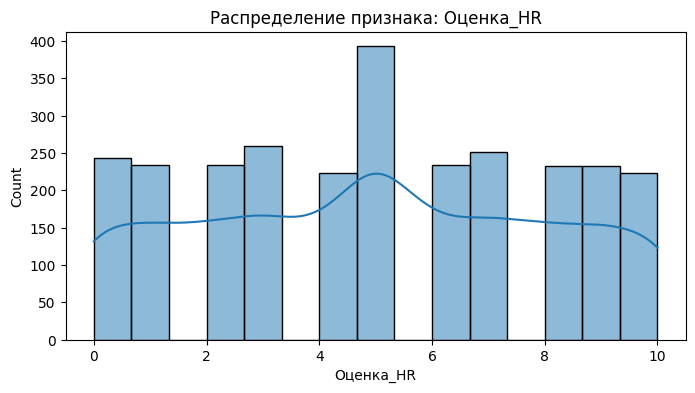

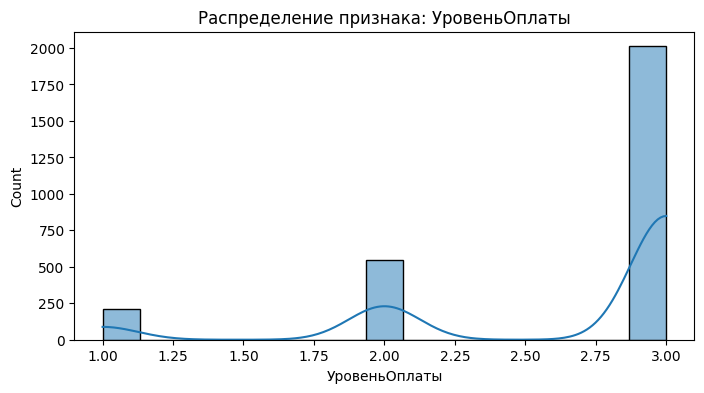

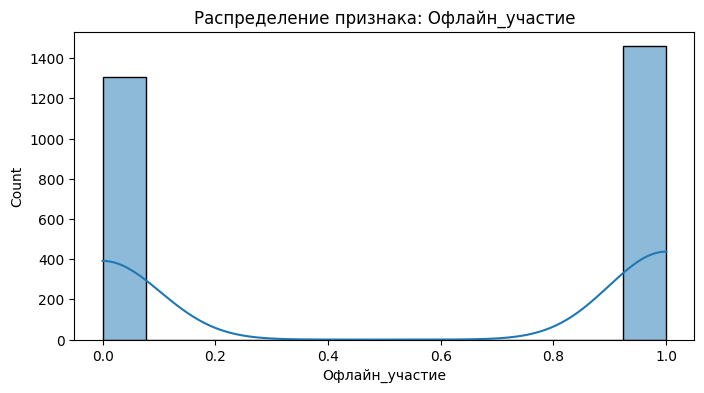

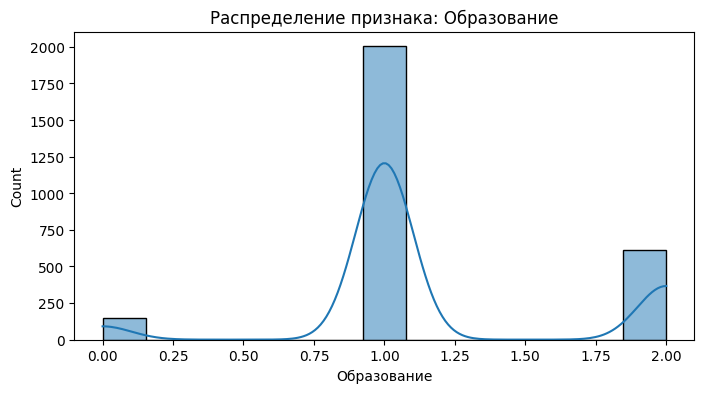

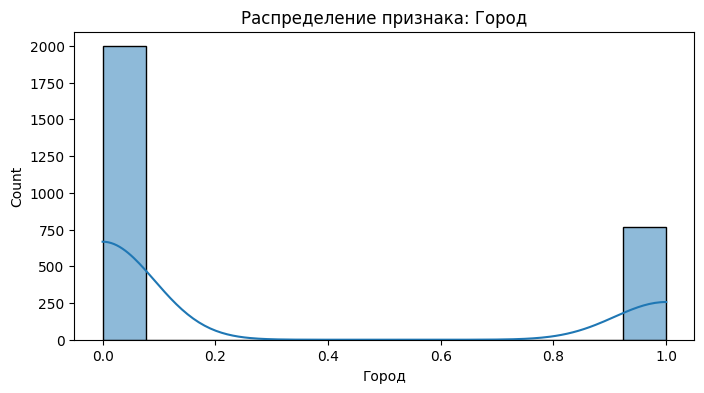

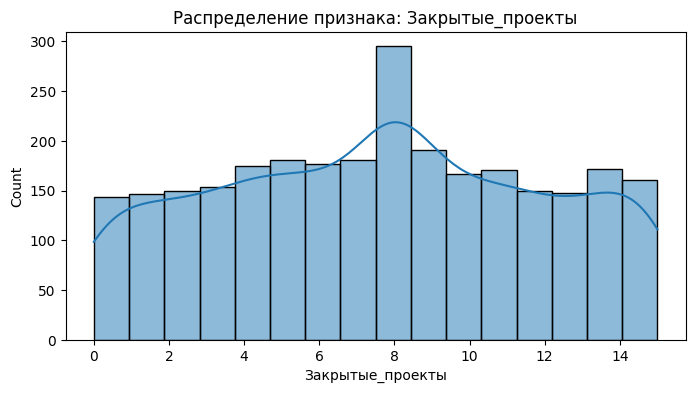

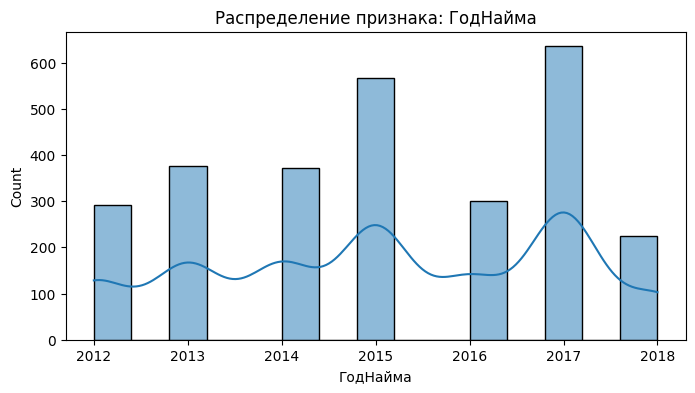

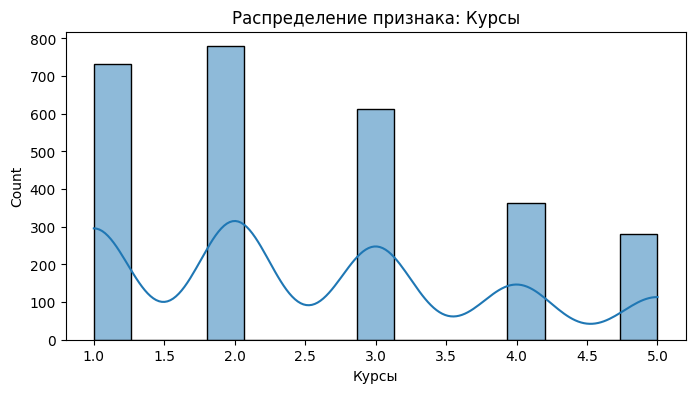

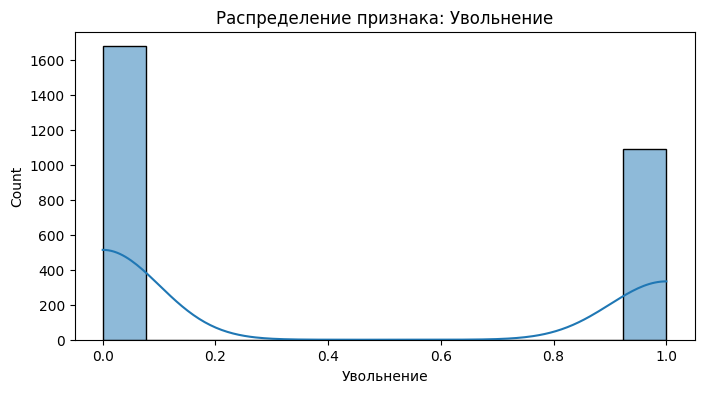

In [ ]:
for col in X.columns:
    plt.figure(figsize=(8, 4))
    if X[col].dtype == 'object':
        sns.countplot(data=X, x=col)
        plt.title(f'Распределение признака: {col}')
    else:
        sns.histplot(data=X, x=col, kde=True)
        plt.title(f'Распределение признака: {col}')
    plt.show()

In [ ]:
# Признак 'БылПростой' имеет слишком ненормальное распределение, следовательно его нецелесообразно использовать
to_drop = ['БылПростой']
cols_to_drop.extend(to_drop)
X = X.drop(columns=to_drop)

In [ ]:
X.head()

,Телефон,Год_рождения,Подписаны_документы,Пол,ОпытВДолжности,Активность,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Образование,Город,Закрытые_проекты,ГодНайма,Курсы,Увольнение
0,911002578495,"1,999.000",1,1,0.000,474.000,28.000,2.000,3.000,0.000,1,0,15.000,"2,016.000",5.000,0
1,911003188573,"1,996.000",1,1,1.000,28.000,29.000,0.000,3.000,0.000,2,0,4.000,"2,014.000",2.000,0
2,911007534727,"1,988.000",0,0,0.000,164.000,39.000,3.000,2.000,0.000,1,0,14.000,"2,015.000",1.000,1
3,911018720091,"1,995.000",0,1,4.000,372.000,30.000,10.000,1.000,0.000,1,0,14.000,"2,016.000",4.000,1
4,911019519742,"1,992.000",0,0,2.000,314.000,35.000,3.000,3.000,1.000,1,0,1.000,"2,014.000",1.000,1


In [ ]:
# Возможная выгода от признака 'Телефон' уже получена, теперь он уникален, для всех строк и не не несет предсказательной ценности
# Признак 'Телефон' исключается из финальной выборки
to_drop = ['Телефон']
cols_to_drop.extend(to_drop)
X = X.drop(columns=to_drop)

In [ ]:
df_test.head()

,Год_рождения,Подписаны_документы,Пол,БылПростой,ОпытВДолжности,Активность,Знак_зодиака,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Образование,Телефон,Город,Размер,Закрытые_проекты,ГодНайма,Курсы
0,1993,NaN,Male,No,2,94,Телец,32,8,2,0,Masters,918364696468,New Delhi,XL,11,2017,1
1,1995,NaN,Male,No,3,6,Весы,31,0,3,1,PHD,919004230452,New Delhi,L,1,2015,3
2,2002,NaN,Female,Yes,2,394,Водолей,24,1,2,0,Bachelors,912758264161,Pune,M,11,2015,1
3,1999,NaN,Male,Yes,5,31,Стрелец,27,1,3,0,Bachelors,912767392867,Bangalore,M,14,2015,3
4,2002,NaN,Male,No,1,167,Стрелец,23,8,2,1,Masters,913215029749,New Delhi,XXL,14,2017,4


In [ ]:
df_test['Подписаны_документы'].unique()

array([nan])

In [ ]:
# В тестовом файле столбец 'Подписаны_документы' пуст, значит мы не будем использовать его для обучения модели. Здесь же можно отбросить таргетный признак 'Увольнение'
to_drop = ['Подписаны_документы', 'Увольнение']
cols_to_drop.extend(to_drop)
X = X.drop(columns=to_drop)

In [ ]:
X.head()

,Год_рождения,Пол,ОпытВДолжности,Активность,Возраст,Оценка_HR,УровеньОплаты,Офлайн_участие,Образование,Город,Закрытые_проекты,ГодНайма,Курсы
0,"1,999.000",1,0.000,474.000,28.000,2.000,3.000,0.000,1,0,15.000,"2,016.000",5.000
1,"1,996.000",1,1.000,28.000,29.000,0.000,3.000,0.000,2,0,4.000,"2,014.000",2.000
2,"1,988.000",0,0.000,164.000,39.000,3.000,2.000,0.000,1,0,14.000,"2,015.000",1.000
3,"1,995.000",1,4.000,372.000,30.000,10.000,1.000,0.000,1,0,14.000,"2,016.000",4.000
4,"1,992.000",0,2.000,314.000,35.000,3.000,3.000,1.000,1,0,1.000,"2,014.000",1.000


## Попробуем обучить модель

In [ ]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Функция для оценки модели
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    return roc_auc

In [ ]:
# Инициализация модели
model = RandomForestClassifier(n_estimators=60, random_state=42, n_jobs=20, max_depth=8)

In [ ]:
model


RandomForestClassifier(max_depth=8, n_estimators=60, n_jobs=20, random_state=42)

In [ ]:
# Базовое качество (все признаки)
auc_base = evaluate_model(model, X_train, X_test, y_train, y_test)
print(f"RF, Базовое ROC-AUC (все признаки): {auc_base:.4f}")
methods.append('RF, Базовое качество')
auc_values.append(auc_base)

RF, Базовое ROC-AUC (все признаки): 0.7025


## Низкая дисперсия

In [ ]:
pd.options.display.float_format = '{:,.3f}'.format
variances = X_train.var()

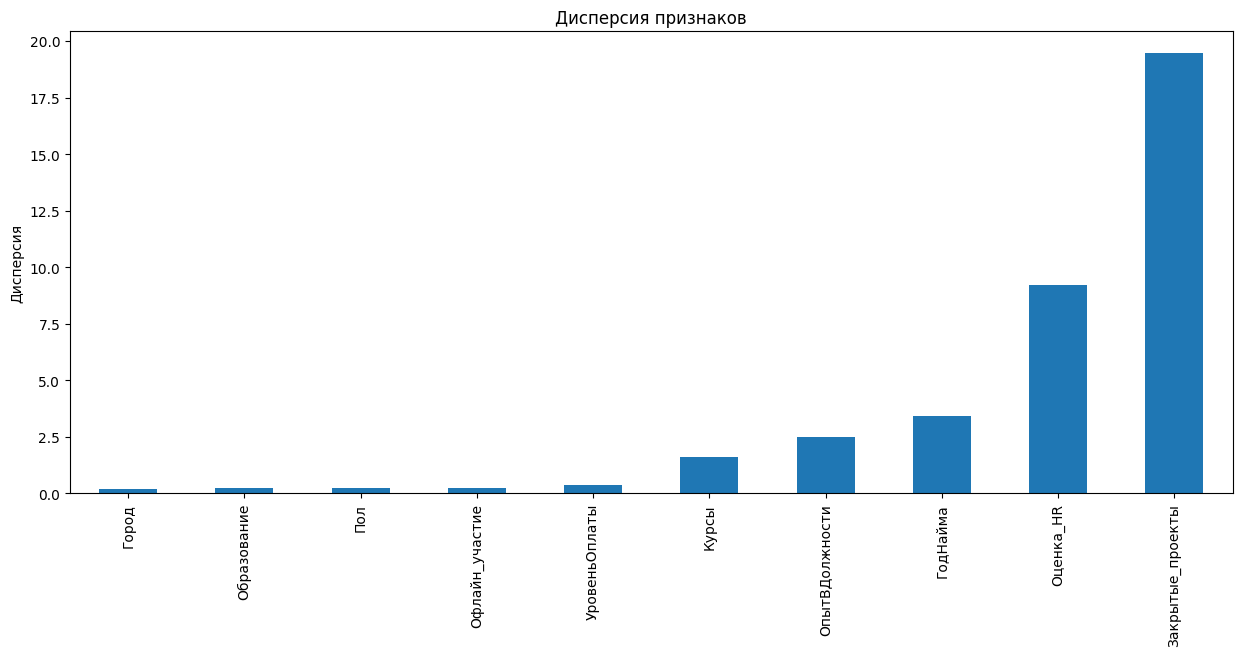

In [ ]:
# Визуализация
plt.figure(figsize=(15, 6))
variances.sort_values().iloc[:-3].plot(kind='bar')
plt.title('Дисперсия признаков')
plt.ylabel('Дисперсия')
plt.show()

In [ ]:
variances.loc[variances<0.01]

,0



## Корреляция

In [ ]:
# Вычисление корреляции
corr_matrix = X_train.corr().abs()

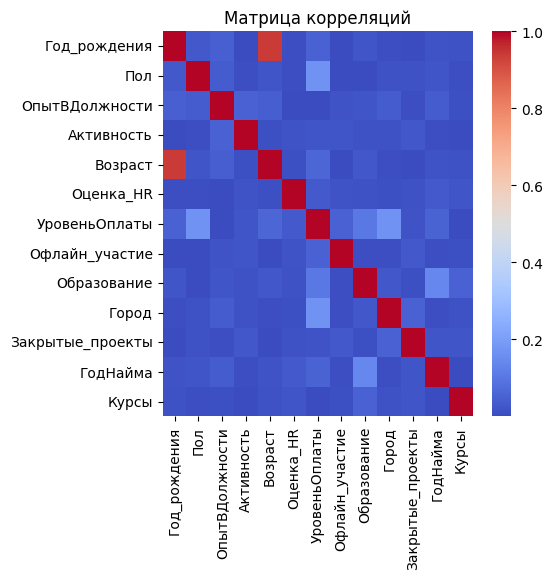

In [ ]:
# Визуализация
plt.figure(figsize=(5, 5))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

In [ ]:
# Удаление высокоскоррелированных признаков (threshold > 0.90)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

SyntaxError: invalid syntax (ipython-input-1930905096.py, line 1)

In [ ]:
to_drop

['Возраст']

In [ ]:
X_train_uncorr = X_train.drop(columns=to_drop)
X_test_uncorr = X_test.drop(columns=to_drop)

In [ ]:
auc_uncorr = evaluate_model(model, X_train_uncorr, X_test_uncorr, y_train, y_test)
print(f"AUC после удаления скоррелированных признаков: {auc_uncorr:.4f}")
print(f"Удалено признаков: {len(to_drop)}")

methods.append('RF, Корреляция')
auc_values.append(auc_uncorr)

AUC после удаления скоррелированных признаков: 0.7095
Удалено признаков: 1


In [ ]:
# Правильное решение. Сохраняем
cols_to_drop.extend(to_drop)

# С целевой переменной

## Feature Importance

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=10)
rf.fit(X_train_uncorr, y_train)

RandomForestClassifier(n_jobs=10, random_state=42)

In [ ]:
# Визуализация важности
importances = pd.Series(rf.feature_importances_, index=X_train_uncorr.columns)
importances = importances.sort_values(ascending=False)

/tmp/ipython-input-1767448839.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


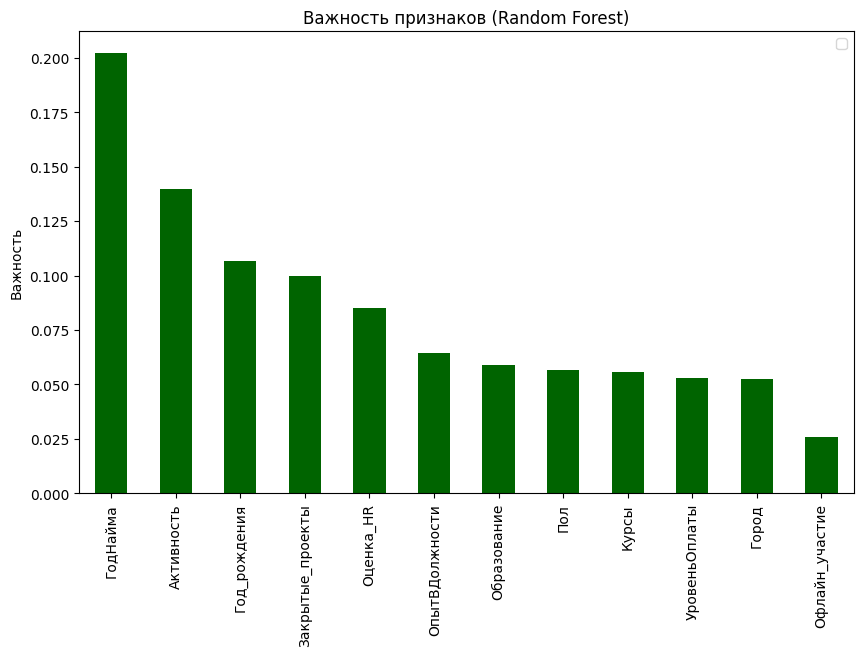

In [ ]:
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='darkgreen')
plt.title('Важность признаков (Random Forest)')
plt.ylabel('Важность')
plt.legend()
plt.show()

In [ ]:
importances.sum()

np.float64(0.9999999999999999)

In [ ]:
importances[importances>0.002]

,0
ГодНайма,0.202
Активность,0.140
Год_рождения,0.106
Закрытые_проекты,0.100
Оценка_HR,0.085
ОпытВДолжности,0.064
Образование,0.059
Пол,0.057
Курсы,0.056
УровеньОплаты,0.053


# SHAP

In [ ]:
import shap
shap.initjs()

In [ ]:
model_new = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=20, max_depth=30)
model_new.fit(X_train, y_train)

RandomForestClassifier(max_depth=30, n_estimators=200, n_jobs=20,
                       random_state=42)

In [ ]:
explainer = shap.TreeExplainer(model)

In [ ]:
# Вычисляем SHAP-значения для тестового набора
shap_values = explainer.shap_values(X_test)

/tmp/ipython-input-2140659189.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot")
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


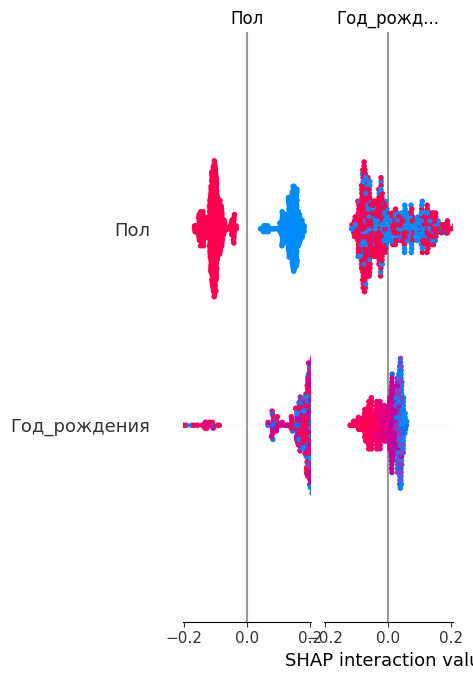

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="dot")

In [ ]:
# Удаляем неважные признаки
to_drop = ['Курсы', 'ГодНайма']
X_train_shapped = X_train_uncorr.drop(columns=to_drop)
X_test_shapped = X_test_uncorr.drop(columns=to_drop)

In [ ]:
auc_sp = evaluate_model(model, X_train_shapped, X_test_shapped, y_train, y_test)
print(f"4. AUC после отбора по важности: {auc_sp:.4f}")
methods.append('RF, Summary Plot')
auc_values.append(auc_sp)

4. AUC после отбора по важности: 0.6208


Не будем сохранять это изменение

In [ ]:
cols_to_drop

['Возраст']

In [ ]:
methods

['RF, Корреляция', 'RF, Summary Plot']

In [ ]:
auc_values

[np.float64(0.7094848484848485), np.float64(0.6207878787878789)]

In [ ]:
# Случайный лес
rf_model = RandomForestClassifier(
    n_estimators=60,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# качество
rf_auc = evaluate_model(model, X_train_uncorr, X_test_uncorr, y_train, y_test)
print(f"RF, ROC-AUC: {rf_auc:.4f}")

RF, ROC-AUC: 0.7095


In [ ]:
cat_model = CatBoostClassifier(iterations=300,
                                 learning_rate=0.1,
                                 depth=8,
                                 loss_function='Logloss',
                                 eval_metric='AUC',
                                 random_seed=42,
                                 verbose=False)

auc_catboost = evaluate_model(cat_model, X_train_uncorr, X_test_uncorr, y_train, y_test)
print(f"CatBoost, ROC-AUC: {auc_catboost:.4f}")
methods.append('CatBoost')
auc_values.append(auc_catboost)

CatBoost, ROC-AUC: 0.7067


Остановимся на Случайном лесе

In [ ]:
!pip freeze > requirements.txt
print("Файл requirements.txt успешно создан.")

Файл requirements.txt успешно создан.
